In [1]:
import joblib
import pandas as pd
import rasterio
import numpy as np

# Constantes definidas en el entrenamiento
MODEL_FILENAME = 'deforestation_model_v4.pkl'
# ¡Esta lista DEBE coincidir exactamente con BANDS_TO_SELECT del entrenamiento!
FEATURE_NAMES = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'EVI', 'SAVI', 'NDWI', 'NDVI_diff', 'elevation', 'slope', 'entropy']

# 1. Cargar el modelo de Random Forest entrenado
try:
    trained_model = joblib.load(MODEL_FILENAME)
    print(f"Modelo {MODEL_FILENAME} cargado exitosamente.")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo del modelo '{MODEL_FILENAME}'.")
    exit()

Modelo deforestation_model_v4.pkl cargado exitosamente.


In [5]:
import joblib
import pandas as pd
import rasterio
import numpy as np
from sklearn.base import ClassifierMixin # Tipo más preciso para Scikit-learn

# Definimos el modelo como un objeto genérico de clasificación de Scikit-learn
def classify_geotiff(geotiff_path: str, model: ClassifierMixin, feature_names: list):
    """
    Lee un GeoTIFF con múltiples bandas de features, aplica la clasificación
    y guarda el resultado como un nuevo GeoTIFF de mapa de clases.
    """
    print(f"\nLeyendo imagen de entrada: {geotiff_path}...")
    
    with rasterio.open(geotiff_path) as src:
        # Extraer metadatos y asegurar que el número de bandas es correcto
        profile = src.profile
        if src.count != len(feature_names):
            print(f"Error: El GeoTIFF tiene {src.count} bandas, se esperaban {len(feature_names)}.")
            return

        # 1. Leer todas las bandas del GeoTIFF
        img_array = src.read()
        
        # 2. Reestructurar el array para el modelo ML
        rows, cols = img_array.shape[1], img_array.shape[2]
        X_test = img_array.transpose(1, 2, 0).reshape(-1, src.count)
        
        # 3. Identificar y manejar valores NaN/Inf
        is_finite = np.all(np.isfinite(X_test), axis=1)
        X_test_clean = X_test[is_finite]
        
        # 4. Aplicar el modelo entrenado (Inferencia)
        print(f"Aplicando clasificación a {len(X_test_clean)} píxeles...")
        
        # >>> APLICACIÓN DEL MODELO RF CARGADO <<<
        # Note: Si el modelo fue entrenado con un Pipeline, esta línea lo maneja.
        y_pred_clean = model.predict(X_test_clean) 
        
        # 5. Reconstruir el mapa de clasificación
        classification_map = np.empty(rows * cols, dtype=np.int16)
        classification_map[:] = 0 # Inicializar todo como Clase 0 ('Otras Tierras')
        classification_map[is_finite] = y_pred_clean
        classification_map = classification_map.reshape(rows, cols)

        # 6. Exportar el resultado a un nuevo GeoTIFF
        profile.update(dtype=rasterio.int16, count=1, compress='lzw')
        output_path = geotiff_path.replace('.tif', '_classified.tif')
        
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(classification_map, 1)
        
        print(f"\n¡Clasificación completada y mapa guardado como '{output_path}'!")
        print("Clases: 0 (Otras Tierras), 1 (Bosque Estable), 2 (Deforestado)")

# --- EJECUCIÓN ---
# Nota: La imagen 'cuenca_features_2024.tif' debe contener las 12 bandas de features.
INPUT_GEOTIFF = 'features_cuenca.tif' 

# Asegúrese de que este GeoTIFF haya sido exportado de GEE
# utilizando la imagen 'final_features' que contiene ['Blue', 'Green', 'Red', 'NIR', 'NDVI', ..., 'entropy']

classify_geotiff(INPUT_GEOTIFF, trained_model, FEATURE_NAMES)


Leyendo imagen de entrada: features_cuenca.tif...
Aplicando clasificación a 14055552 píxeles...


/home/sebastians/anaconda3/envs/geo-ml/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



¡Clasificación completada y mapa guardado como 'features_cuenca_classified.tif'!
Clases: 0 (Otras Tierras), 1 (Bosque Estable), 2 (Deforestado)


Cargando modelo desde: deforestation_model_v4.pkl
Muestras de prueba cargadas: 3583 píxeles.
Realizando predicciones en el conjunto de prueba...

--- REPORTE DE CLASIFICACIÓN ---
                   precision    recall  f1-score   support

Otras Tierras (0)       0.75      0.74      0.74      1169
       Bosque (1)       0.64      0.63      0.63      1199
  Deforestado (2)       0.58      0.60      0.59      1215

         accuracy                           0.65      3583
        macro avg       0.65      0.65      0.65      3583
     weighted avg       0.65      0.65      0.65      3583


Precisión General (Accuracy): 0.6522
Generando Matriz de Confusión...
Matriz de confusión guardada como 'confusion_matrix_final.png'


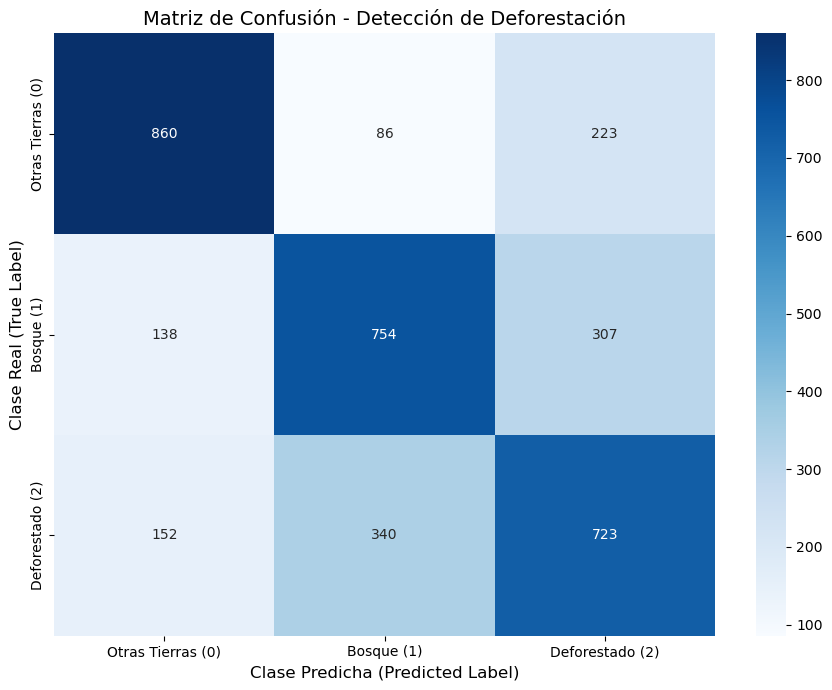

In [9]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- CONSTANTES ---
MODEL_FILENAME = 'deforestation_model_v4.pkl'
TEST_SAMPLES_FILE = 'testing_samples.csv'
CLASS_LABELS = ['Otras Tierras (0)', 'Bosque (1)', 'Deforestado (2)']
TARGET_COLUMN = 'class' 

# --- PASO 1: CARGAR MODELO Y DATOS DE PRUEBA ---
print(f"Cargando modelo desde: {MODEL_FILENAME}")
try:
    classifier = joblib.load(MODEL_FILENAME)
    test_df = pd.read_csv(TEST_SAMPLES_FILE)
    print(f"Muestras de prueba cargadas: {len(test_df)} píxeles.")
except FileNotFoundError as e:
    print(f"Error: Asegúrese de que los archivos existan: {e}")
    exit()

# --- CONSTANTES ---
# ... (otras constantes, asumiendo que 'features' se define correctamente)
TARGET_COLUMN = 'class' 
# Las características que se usaron en el entrenamiento (definidas en el notebook):
EXPECTED_FEATURES = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'EVI', 'SAVI', 'NDWI', 'NDVI_diff', 'elevation', 'slope', 'entropy']


# --- PASO 1: CARGAR MODELO Y DATOS DE PRUEBA ---
# ... (código de carga omitido por brevedad)

# Separar características (X) y objetivo (y)
test_df = pd.read_csv(TEST_SAMPLES_FILE)

# 1. IDENTIFICAR CARACTERÍSTICAS:
# Usamos la lista de características esperadas (EXPECTED_FEATURES) para la selección.
# Esto asegura que no se incluyan columnas como 'system:index' o 'random'.
X_test_initial = test_df[EXPECTED_FEATURES] # <--- Seleccionamos SOLO las columnas esperadas

# 2. APLICAR EL ORDEN CRÍTICO:
# Forzamos que X_test tenga las columnas en el orden exacto de EXPECTED_FEATURES.
X_test = X_test_initial[EXPECTED_FEATURES] # <--- Esto es CRUCIAL para Scikit-learn

y_test = test_df[TARGET_COLUMN]

# --- PASO 2: REALIZAR PREDICCIONES (CORREGIDO) ---
print("Realizando predicciones en el conjunto de prueba...")
# La predicción ahora funciona porque X_test tiene los nombres y el orden correcto
y_pred = classifier.predict(X_test) 

# --- PASO 3: EVALUACIÓN DEL MODELO ---
# ... (código de evaluación que ya funciona)
# Separar características (X) y objetivo (y)
# Excluimos las columnas que no son features (ej. 'system:index', 'random', 'class')
# --- PASO 3: EVALUACIÓN DEL MODELO (Métricas) ---
print("\n--- REPORTE DE CLASIFICACIÓN ---")
# Generar el reporte con precisión, recall y F1-score
report = classification_report(y_test, y_pred, target_names=CLASS_LABELS)
print(report)

# La precisión general (accuracy) es la última línea del reporte:
accuracy = (y_test == y_pred).mean()
print(f"\nPrecisión General (Accuracy): {accuracy:.4f}")


# --- PASO 4: VISUALIZAR MATRIZ DE CONFUSIÓN ---
print("Generando Matriz de Confusión...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=CLASS_LABELS, 
    yticklabels=CLASS_LABELS
)
plt.title('Matriz de Confusión - Detección de Deforestación', fontsize=14)
plt.ylabel('Clase Real (True Label)', fontsize=12)
plt.xlabel('Clase Predicha (Predicted Label)', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_final.png')
print("Matriz de confusión guardada como 'confusion_matrix_final.png'")